
<h1 align="center"> Statistics and Financial Data Analysis
<h1 align="center"> Examples


In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math
import scipy as sp
from statsmodels.distributions.empirical_distribution import ECDF

In [2]:
np.random.seed(17)

mu = 0
std = 0.4

a = 2
b = 0.5

# Create random variable from distribution used
rv = stats.norm(mu,std)
n = 2000
    
def f(x,a,b,rv):
    n = x.size
    y = np.zeros(n)
    y_data = np.zeros(n)
    y_1 = np.zeros(n)
    y_2 = np.zeros(n)
    z = rv.rvs(size = n)
    for i in range(n):
        y_data[i] = a*x[i]+b + z[i]
        y[i] = a*x[i]+b 
        y_1[i] = a*1.2*x[i]-1.2 
        y_2[i] = a*0.9*x[i]+1.1 
    return y_data,y,y_1,y_2

In [3]:
x = np.linspace(0,10, n)
yd,y,y_1,y_2 = f(x,a,b,rv)

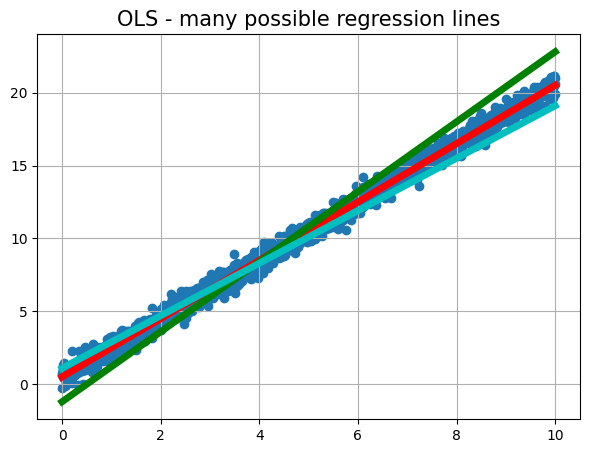

In [4]:
plt.figure(1, figsize=(7,5)) 
plt.scatter(x,yd)
plt.plot(x,y,'r',linewidth= 5)
plt.plot(x,y_1,'g',linewidth= 5)
plt.plot(x,y_2,'c',linewidth= 5)
plt.title('OLS - many possible regression lines', fontsize = 15)
plt.grid()

In [5]:
import statsmodels.api as sm

X = x
y = yd
Xnew = sm.add_constant(X)
model = sm.OLS(y, Xnew).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 4.060e+05
Date:                Sun, 02 Oct 2022   Prob (F-statistic):               0.00
Time:                        11:44:57   Log-Likelihood:                -1034.7
No. Observations:                2000   AIC:                             2073.
Df Residuals:                    1998   BIC:                             2085.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5001      0.018     27.546      0.000       0.465       0.536
x1             2.0035      0.003    637.191      0.000       1.997       2.010
==============================================================================
Omnibus:                        2.406   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.300   Jarque-Bera (JB):                2.351
Skew:                          -0.056   Prob(JB):                        0.309
Kurtosis:                       3.125   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

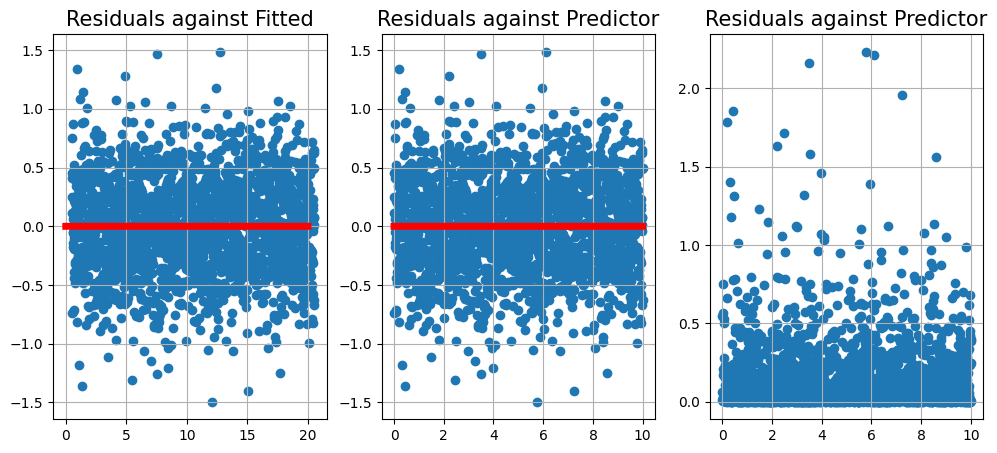

In [6]:
y_fitted = model.predict(Xnew) # make the predictions by the model
res = model.resid

plt.figure(figsize=(12,5))
plt.subplot(1,3, 1)
plt.scatter(y_fitted,res)
plt.plot(a*x,np.zeros(n),'r',linewidth = 5)
plt.title('Residuals against Fitted', fontsize = 15)
plt.grid()
plt.subplot(1,3, 2)
plt.scatter(x,res)
plt.plot(x,np.zeros(n),'r',linewidth = 5)
plt.title('Residuals against Predictor', fontsize = 15)
plt.grid()
plt.subplot(1,3, 3)
resSqr = res**2
plt.scatter(x,resSqr)
plt.title('Residuals against Predictor', fontsize = 15)
plt.grid()


In [7]:
print("Sum of all residuals = ", res.sum())
print("Cov of residual with predictor = ", np.cov(x,res)[0,1])
print("Cov of residual with fitted values = ", np.cov(y_fitted,res)[0,1])

Sum of all residuals =  -1.1100453889412165e-11
Cov of residual with predictor =  4.806449274492761e-15
Cov of residual with fitted values =  9.655774595759439e-15


In [8]:
np.random.seed(17)

In [9]:
x = x
y = yd
m = 1000

param0 = np.zeros(m)
param1 = np.zeros(m)

# Create random variable from distribution used
mu = 0
std = 0.5
rv = stats.norm(mu,std)
z = np.zeros(n)

a = 2
b = 0.5
X = sm.add_constant(x)

for i in range(m):
    z = rv.rvs(size = n)
    yd = np.zeros(n)
    for j in range(n):
        yd[j] = a*x[j] + b + z[j]
    model = sm.OLS(yd, X).fit()
    param0[i] = model.params[0]
    param1[i] = model.params[1]

print("Expected estimates of coefficient beta 0: ", param0.mean())
print("Actual coefficient beta 0: ", b)
print("Expected estimates of coefficient beta 1: ", param1.mean())
print("Actual coefficient beta 1: ", a)


Expected estimates of coefficient beta 0:  0.49955891872245417
Actual coefficient beta 0:  0.5
Expected estimates of coefficient beta 1:  2.000123995160792
Actual coefficient beta 1:  2
